In [54]:
import pandas as pd

sales_df = pd.read_excel("..\data\store_last3months_sales.xlsx")
daily_df = pd.read_excel("..\data\store-Daily-Sales 2.xlsx")

sales_df.head()

,Product,Barcode,Order,Product Quantity,Total Price,Average Sales Price,Average Cost Price,Margin
0,NaN,NaN,37523,190647.26,678839.47,NaN,NaN,NaN
1,Snacks & Sweets / Candy & Cadbury,NaN,1945,2835.00,8665.56,NaN,NaN,4123.86
2,oddie dubai chocolate pista 27g,8681657415755,195,256.00,637.44,2.49,1.00,381.44
3,Cadbury Twirl,5000201499776,38,61.00,121.39,1.99,1.00,60.39
4,Cadbury Wholenut 120G,5034660521877,22,23.00,91.77,3.99,1.87,48.76


In [55]:
daily_df.head()

,Order Date,Product,Barcode,Product Category,Product Quantity,Total Price,Average Price,Average Cost,Margin
0,1 (130709),NaN,NaN,NaN,198134.64,706071.89,NaN,NaN,NaN
1,[00] Manual (341),NaN,NaN,NaN,770.80,1529.50,3.544463,-0.000007,1529.5
2,2025-11-09 20:36:53,[00] Manual,00,All,2.00,2.00,1.000000,0.000000,2.0
3,2025-11-09 12:19:16,[00] Manual,00,All,2.00,2.00,1.000000,0.000000,2.0
4,2025-11-09 10:34:06,[00] Manual,00,All,1.00,1.00,1.000000,0.000000,1.0


In [56]:
print(sales_df.columns)
print(daily_df.columns)

Index(['Product', 'Barcode', 'Order', 'Product Quantity', 'Total Price',
       'Average Sales Price', 'Average Cost Price', 'Margin'],
      dtype='object')
Index(['Order Date', 'Product', 'Barcode', 'Product Category',
       'Product Quantity', 'Total Price', 'Average Price', 'Average Cost',
       'Margin'],
      dtype='object')


In [57]:
def preprocess_data(df):

    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )

    df = df.dropna(how="all")

    df = df.drop_duplicates()

    df = df.dropna(
        subset=[
            "product",
            "product_quantity",
            "total_price"
        ]
    )

    df["product_quantity"] = pd.to_numeric(
        df["product_quantity"],
        errors="coerce"
    )

    df["total_price"] = pd.to_numeric(
        df["total_price"],
        errors="coerce"
    )

    df = df.dropna(
        subset=[
            "product_quantity",
            "total_price"
        ]
    )

    return df

In [58]:
clean_sales_df = preprocess_data(sales_df)
clean_daily_df = preprocess_data(daily_df)

In [59]:
clean_daily_df["order_date"] = pd.to_datetime(
    clean_daily_df["order_date"],
    errors="coerce"
)

clean_daily_df = clean_daily_df.dropna(
    subset=["order_date"]
)

KPIS generated

In [60]:
product_stats = clean_sales_df.groupby("product").agg(
    total_quantity_sold=("product_quantity", "sum"),
    total_revenue=("total_price", "sum"),
    average_quantity_sold=("product_quantity", "mean"),
    average_revenue=("total_price", "mean"),
    number_of_records=("product", "count")
).reset_index()

product_stats = product_stats.sort_values(
    by="total_revenue",
    ascending=False
)

product_stats.head(10)

,product,total_quantity_sold,total_revenue,average_quantity_sold,average_revenue,number_of_records
46,Fruits & Vegetables / Produces & Fruit,83911.62,126897.52,83911.62,126897.52,1
53,Meat / CHICKEN,19783.88,90149.60,19783.88,90149.60,1
55,Meat / GOAT / LAMB,6276.61,81963.02,6276.61,81963.02,1
52,Jalebi & DD Rotis,13479.00,79087.81,13479.00,79087.81,1
768,Chkn Whole Cut,11091.03,47555.90,11091.03,47555.90,1
1811,Jalebi Yellow 1lb,3812.50,45684.42,3812.50,45684.42,1
36,Dairy Products / Dairy,5694.23,35404.58,5694.23,35404.58,1
72,"Rice, Grains & Flour Products / Rice",1756.63,31897.66,1756.63,31897.66,1
1532,Goat Mix,2042.14,24469.70,2042.14,24469.70,1
81,Snacks & Sweets / Snacks,7556.55,23767.91,7556.55,23767.91,1


In [61]:
import matplotlib.pyplot as plt

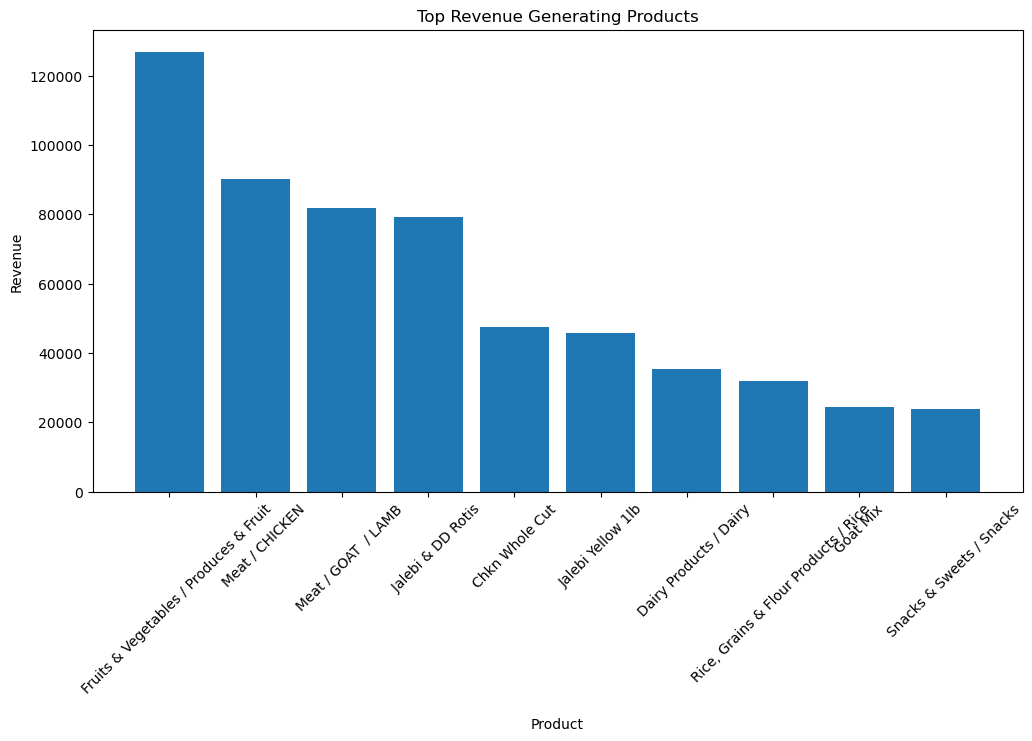

In [62]:
top_products = product_stats.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_products["product"],
    top_products["total_revenue"]
)

plt.xticks(rotation=45)
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.title("Top Revenue Generating Products")
plt.show()

In [63]:
product_forecast = clean_sales_df.groupby("product").agg(
    total_quantity_sold=("product_quantity", "sum"),
    total_revenue=("total_price", "sum"),
    average_quantity_sold=("product_quantity", "mean")
).reset_index()

product_forecast["predicted_60_day_quantity"] = (
    product_forecast["average_quantity_sold"] * 60
)

product_forecast["reason"] = (
    "Prediction is based on average quantity sold during the given timeframe."
)

In [64]:
worst_10_products = product_forecast.sort_values(
    by="predicted_60_day_quantity",
    ascending=True
).head(10)

worst_10_products

,product,total_quantity_sold,total_revenue,average_quantity_sold,predicted_60_day_quantity,reason
24,All / Deliveries,0.00,0.00,0.00,0.0,Prediction is based on average quantity sold d...
4098,priyems idli - dosa 1800 gm,0.00,0.00,0.00,0.0,Prediction is based on average quantity sold d...
417,Ankur Copper Water Bottle,0.00,0.00,0.00,0.0,Prediction is based on average quantity sold d...
3621,Test,0.00,0.00,0.00,0.0,Prediction is based on average quantity sold d...
1192,Drumsticks Fresh / Lb,0.46,2.76,0.46,27.6,Prediction is based on average quantity sold d...
1190,Drumstick Leaves/ Lb,0.60,3.89,0.60,36.0,Prediction is based on average quantity sold d...
3839,Valor Long/Lb,0.76,3.79,0.76,45.6,Prediction is based on average quantity sold d...
1810,Jalapenos Chilli / Lb,0.95,2.37,0.95,57.0,Prediction is based on average quantity sold d...
21,pia beauty ubtan bath powder,1.00,7.99,1.00,60.0,Prediction is based on average quantity sold d...
2516,Mothers Veg Makhanwala Mix 75g,1.00,1.29,1.00,60.0,Prediction is based on average quantity sold d...


In [65]:
top_10_products = product_forecast.sort_values(
    by="predicted_60_day_quantity",
    ascending=False
).head(10)

top_10_products

,product,total_quantity_sold,total_revenue,average_quantity_sold,predicted_60_day_quantity,reason
46,Fruits & Vegetables / Produces & Fruit,83911.62,126897.52,83911.62,5034697.2,Prediction is based on average quantity sold d...
53,Meat / CHICKEN,19783.88,90149.60,19783.88,1187032.8,Prediction is based on average quantity sold d...
52,Jalebi & DD Rotis,13479.00,79087.81,13479.00,808740.0,Prediction is based on average quantity sold d...
768,Chkn Whole Cut,11091.03,47555.90,11091.03,665461.8,Prediction is based on average quantity sold d...
779,Cilantro - Per Bunch,9253.31,4185.30,9253.31,555198.6,Prediction is based on average quantity sold d...
1606,Green Lime Each,8369.26,1957.32,8369.26,502155.6,Prediction is based on average quantity sold d...
81,Snacks & Sweets / Snacks,7556.55,23767.91,7556.55,453393.0,Prediction is based on average quantity sold d...
939,Dd Roti 8Ct,6687.50,15583.17,6687.50,401250.0,Prediction is based on average quantity sold d...
55,Meat / GOAT / LAMB,6276.61,81963.02,6276.61,376596.6,Prediction is based on average quantity sold d...
36,Dairy Products / Dairy,5694.23,35404.58,5694.23,341653.8,Prediction is based on average quantity sold d...


In [66]:
worst_10_products = product_forecast.sort_values(
    by="predicted_60_day_quantity",
    ascending=True
).head(10)

worst_10_products

,product,total_quantity_sold,total_revenue,average_quantity_sold,predicted_60_day_quantity,reason
24,All / Deliveries,0.00,0.00,0.00,0.0,Prediction is based on average quantity sold d...
4098,priyems idli - dosa 1800 gm,0.00,0.00,0.00,0.0,Prediction is based on average quantity sold d...
417,Ankur Copper Water Bottle,0.00,0.00,0.00,0.0,Prediction is based on average quantity sold d...
3621,Test,0.00,0.00,0.00,0.0,Prediction is based on average quantity sold d...
1192,Drumsticks Fresh / Lb,0.46,2.76,0.46,27.6,Prediction is based on average quantity sold d...
1190,Drumstick Leaves/ Lb,0.60,3.89,0.60,36.0,Prediction is based on average quantity sold d...
3839,Valor Long/Lb,0.76,3.79,0.76,45.6,Prediction is based on average quantity sold d...
1810,Jalapenos Chilli / Lb,0.95,2.37,0.95,57.0,Prediction is based on average quantity sold d...
21,pia beauty ubtan bath powder,1.00,7.99,1.00,60.0,Prediction is based on average quantity sold d...
2516,Mothers Veg Makhanwala Mix 75g,1.00,1.29,1.00,60.0,Prediction is based on average quantity sold d...


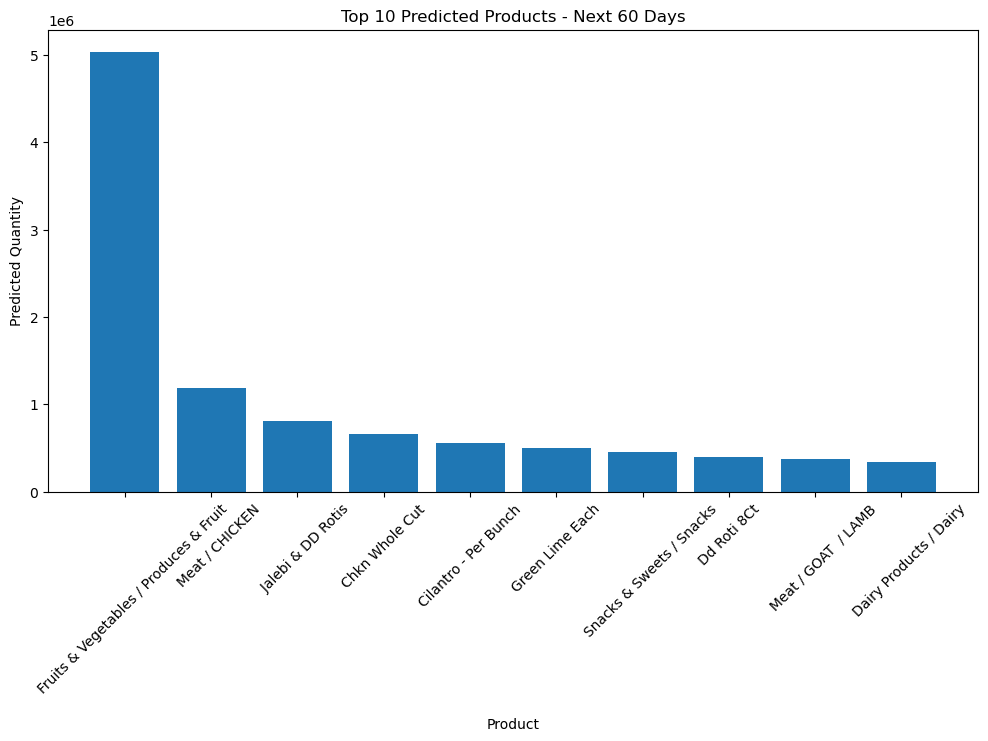

In [67]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_10_products["product"],
    top_10_products["predicted_60_day_quantity"]
)

plt.xticks(rotation=45)
plt.xlabel("Product")
plt.ylabel("Predicted Quantity")
plt.title("Top 10 Predicted Products - Next 60 Days")
plt.show()

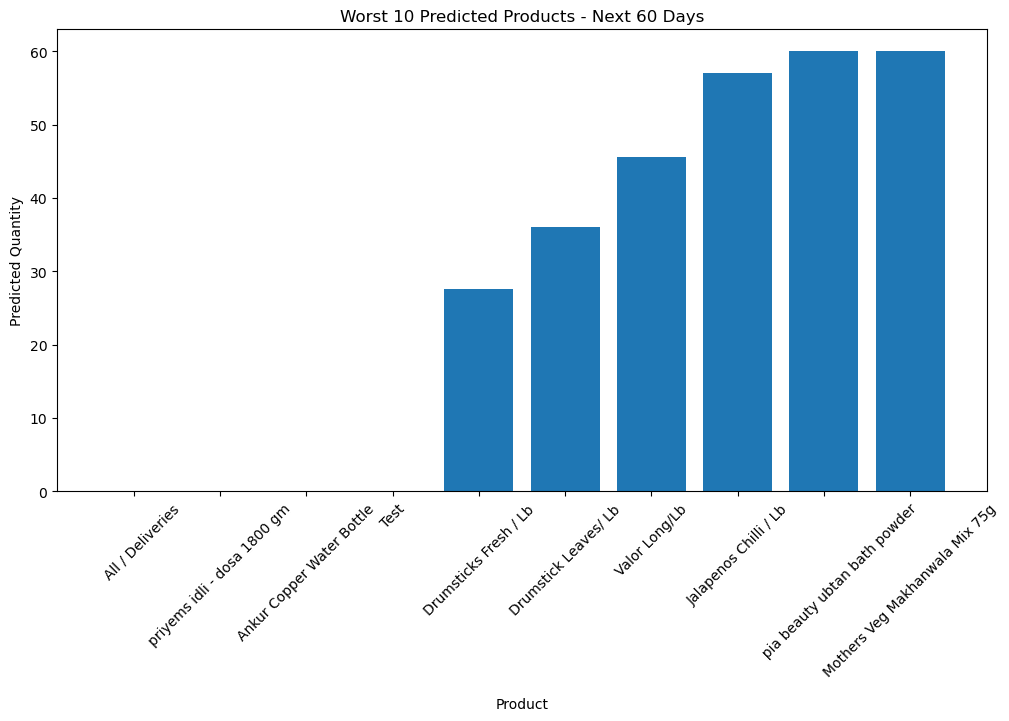

In [68]:
plt.figure(figsize=(12, 6))

plt.bar(
    worst_10_products["product"],
    worst_10_products["predicted_60_day_quantity"]
)

plt.xticks(rotation=45)
plt.xlabel("Product")
plt.ylabel("Predicted Quantity")
plt.title("Worst 10 Predicted Products - Next 60 Days")
plt.show()

In [69]:
import numpy as np

In [70]:
revenue_inventory = clean_sales_df.groupby("product").agg(
    average_quantity_sold=("product_quantity", "mean"),
    total_quantity_sold=("product_quantity", "sum"),
    total_revenue=("total_price", "sum")
).reset_index()

revenue_inventory["estimated_price_per_unit"] = (
    revenue_inventory["total_revenue"] /
    revenue_inventory["total_quantity_sold"].replace(0, np.nan)
)

revenue_inventory["estimated_price_per_unit"] = (
    revenue_inventory["estimated_price_per_unit"].fillna(0)
)

revenue_inventory["projected_60_day_quantity"] = (
    revenue_inventory["average_quantity_sold"] * 60
)

revenue_inventory["projected_60_day_revenue"] = (
    revenue_inventory["projected_60_day_quantity"] *
    revenue_inventory["estimated_price_per_unit"]
)

revenue_inventory["recommended_inventory_order"] = (
    revenue_inventory["projected_60_day_quantity"] * 1.10
).round()

revenue_inventory["reason"] = (
    "Inventory recommendation uses projected 60-day demand with 10% safety stock."
)

revenue_inventory.head(10)

,product,average_quantity_sold,total_quantity_sold,total_revenue,estimated_price_per_unit,projected_60_day_quantity,projected_60_day_revenue,recommended_inventory_order,reason
0,$ 3.99 on specific products,17.0,17.0,-67.83,-3.990000,1020.0,-4069.8,1122.0,Inventory recommendation uses projected 60-day...
1,$ 5.99 on Vajra Sona Masoori Rice 20LB,72.0,72.0,-431.28,-5.990000,4320.0,-25876.8,4752.0,Inventory recommendation uses projected 60-day...
2,$ 5.99 on Vajra Sona Masoori Rice 20...,1.0,1.0,-5.99,-5.990000,60.0,-359.4,66.0,Inventory recommendation uses projected 60-day...
3,$ 5.99 on specific products,389.0,389.0,-1977.11,-5.082545,23340.0,-118626.6,25674.0,Inventory recommendation uses projected 60-day...
4,BOGO HAPPY LEAF IDLY RAVA 4LB,5.0,5.0,-29.95,-5.990000,300.0,-1797.0,330.0,Inventory recommendation uses projected 60-day...
5,Buy 2 @ $2.99 on Bambino Snacks,7.0,7.0,-6.93,-0.990000,420.0,-415.8,462.0,Inventory recommendation uses projected 60-day...
6,Buy 2 @ $5 Green Harvest Millet Noodles,30.0,30.0,-29.40,-0.980000,1800.0,-1764.0,1980.0,Inventory recommendation uses projected 60-day...
7,Buy 2 @$4 Parle Chatkeens,26.0,26.0,-25.48,-0.980000,1560.0,-1528.8,1716.0,Inventory recommendation uses projected 60-day...
8,Buy 2 Get 1 Free Kitchen Xpress 312g,30.0,30.0,-89.70,-2.990000,1800.0,-5382.0,1980.0,Inventory recommendation uses projected 60-day...
9,Dussehra Special Offer on Chkn Whole...,81.0,81.0,-226.79,-2.799877,4860.0,-13607.4,5346.0,Inventory recommendation uses projected 60-day...


In [71]:
from sklearn.linear_model import LinearRegression
daily_revenue = clean_daily_df.groupby("order_date").agg(
    daily_revenue=("total_price", "sum")
).reset_index()

daily_revenue = daily_revenue.sort_values("order_date")

daily_revenue["day_number"] = np.arange(
    len(daily_revenue)
)

daily_revenue.head()

,order_date,daily_revenue,day_number
0,2025-08-01 07:55:35,5.97,0
1,2025-08-01 08:02:08,6.98,1
2,2025-08-01 08:11:55,20.28,2
3,2025-08-01 08:22:39,1.69,3
4,2025-08-01 08:25:05,15.64,4


In [72]:
X = daily_revenue[["day_number"]]
y = daily_revenue["daily_revenue"]
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [73]:
future_days = 60

future_X = pd.DataFrame({
    "day_number": np.arange(
        len(daily_revenue),
        len(daily_revenue) + future_days
    )
})

predicted_revenue = model.predict(
    future_X
)

future_dates = pd.date_range(
    start=daily_revenue["order_date"].max() + pd.Timedelta(days=1),
    periods=future_days
)

daily_revenue_forecast = pd.DataFrame({
    "date": future_dates,
    "predicted_revenue": predicted_revenue
})

daily_revenue_forecast.head()

,date,predicted_revenue
0,2025-11-10 21:31:29,17.175726
1,2025-11-11 21:31:29,17.175678
2,2025-11-12 21:31:29,17.175630
3,2025-11-13 21:31:29,17.175582
4,2025-11-14 21:31:29,17.175533


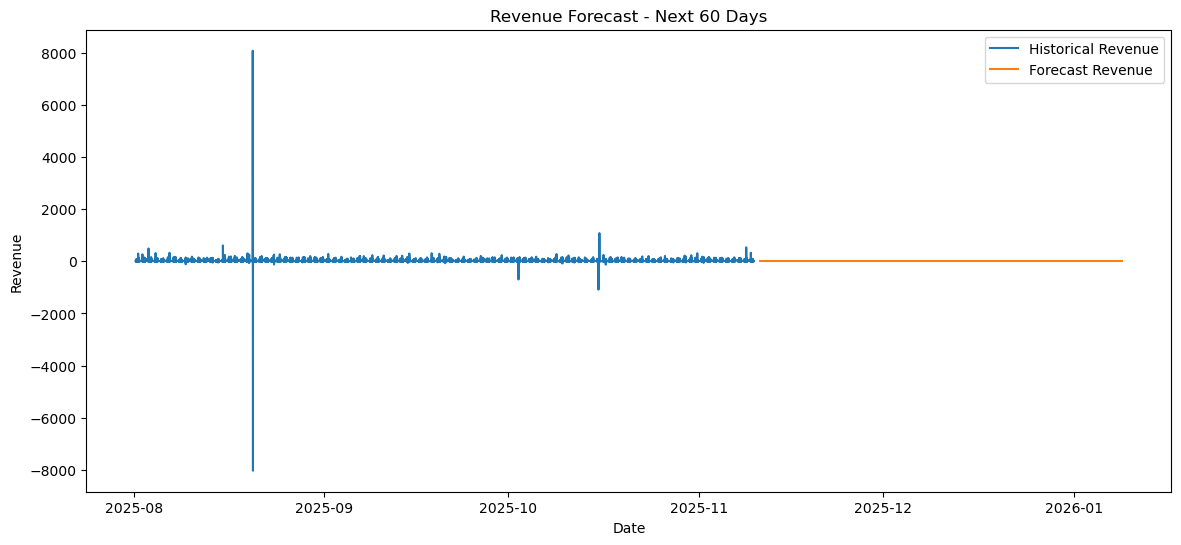

In [74]:
plt.figure(figsize=(14, 6))
plt.plot(
    daily_revenue["order_date"],
    daily_revenue["daily_revenue"],
    label="Historical Revenue"
)

plt.plot(
    future_dates,
    predicted_revenue,
    label="Forecast Revenue"
)

plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Revenue Forecast - Next 60 Days")
plt.legend()
plt.show()

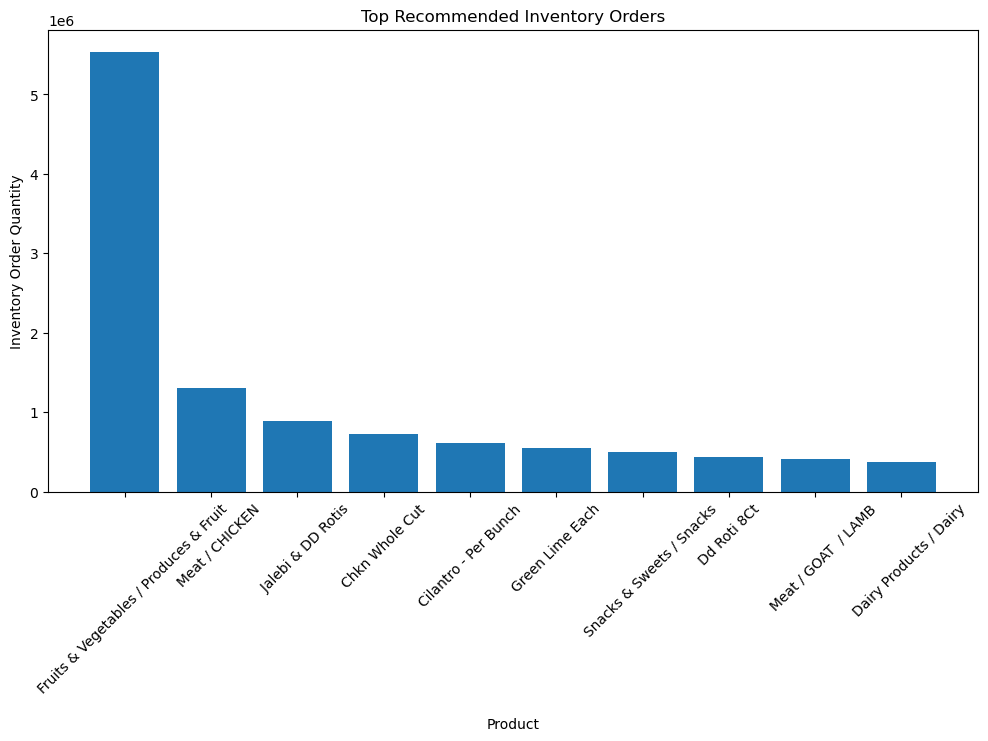

In [75]:
top_inventory = revenue_inventory.sort_values(
    by="recommended_inventory_order",
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_inventory["product"],
    top_inventory["recommended_inventory_order"]
)

plt.xticks(rotation=45)
plt.xlabel("Product")
plt.ylabel("Inventory Order Quantity")
plt.title("Top Recommended Inventory Orders")
plt.show()

In [76]:
import os

# Create output folder
os.makedirs("../output", exist_ok=True)

clean_sales_df.to_csv(
    "../output/clean_sales_data.csv",
    index=False
)

clean_daily_df.to_csv(
    "../output/clean_daily_data.csv",
    index=False
)

product_stats.to_csv(
    "../output/task1_product_stats.csv",
    index=False
)

product_forecast.to_csv(
    "../output/task2_product_forecast.csv",
    index=False
)

top_10_products.to_csv(
    "../output/task2_top_10_products.csv",
    index=False
)

worst_10_products.to_csv(
    "../output/task2_worst_10_products.csv",
    index=False
)

revenue_inventory.to_csv(
    "../output/task3_revenue_inventory.csv",
    index=False
)

daily_revenue.to_csv(
    "../output/task3_daily_revenue.csv",
    index=False
)

daily_revenue_forecast.to_csv(
    "../output/task3_daily_revenue_forecast.csv",
    index=False
)

print("All CSV output files saved successfully in ../output/")

All CSV output files saved successfully in ../output/
